# 재활성화(win-back) 기준일 탐색 — 구매 공백(gap) 세밀 분석

**목적**: H1 담당 팀원이 월 단위(1개월/2개월/3개월+)로 나눈 재활성화 이벤트를,
1. **주 단위**로 더 세밀하게 봐서 실제 복귀율이 꺾이는 지점(elbow)을 찾고
2. **정상 구매주기 대비 몇 배** 이탈인지 수치로 환산하고
3. **가구(household) 단위**로 재구성해서 컷오프 후보별 영향받는 가구 수를 확인한다

이전 EDA 노트북과 동일하게 `data/` 폴더의 8개 CSV를 사용합니다. (transaction_data만 있으면 됨)


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)

DATA_DIR = "data/"
tx = pd.read_csv(DATA_DIR + "transaction_data.csv")

print(tx.shape)
tx[["household_key", "DAY", "WEEK_NO", "BASKET_ID", "SALES_VALUE"]].head()


(2595732, 12)


,household_key,DAY,WEEK_NO,BASKET_ID,SALES_VALUE
0,2375,1,1,26984851472,1.39
1,2375,1,1,26984851472,0.82
2,2375,1,1,26984851472,0.99
3,2375,1,1,26984851472,1.21
4,2375,1,1,26984851472,1.50


In [10]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 시스템에 설치된 한글 폰트 자동 탐색 (Windows 기준 '맑은 고딕' 우선)
candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic"]
available = {f.name for f in fm.fontManager.ttflist}

font_name = next((c for c in candidates if c in available), None)

if font_name:
    plt.rcParams["font.family"] = font_name
else:
    print("한글 폰트를 찾지 못했습니다. 나눔고딕 설치 필요: https://hangeul.naver.com/font 에서 다운로드 후 재시작")

plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

## 1. 가구별 구매일(DAY) 시퀀스와 구매 간격(gap) 계산

- 가구별로 **구매가 있었던 날짜(DAY)만** 중복 제거 후 오름차순 정렬
- 연속된 구매일 사이의 간격(gap, 일 단위)을 계산 — 이게 "며칠 쉬었다가 다시 왔는가"의 원본 데이터
- 첫 구매는 이전 구매가 없으므로 gap이 없음(제외)


In [11]:
# 가구 x 구매일 유니크 조합
purchase_days = (
    tx[["household_key", "DAY"]]
    .drop_duplicates()
    .sort_values(["household_key", "DAY"])
)

# 가구별로 이전 구매일과의 차이(gap, 일 단위) 계산
purchase_days["prev_day"] = purchase_days.groupby("household_key")["DAY"].shift(1)
purchase_days["gap_days"] = purchase_days["DAY"] - purchase_days["prev_day"]

# 첫 구매(gap 없음) 제외한 실제 gap 이벤트만
gaps = purchase_days.dropna(subset=["gap_days"]).copy()
gaps["gap_days"] = gaps["gap_days"].astype(int)
gaps["gap_weeks"] = gaps["gap_days"] / 7

print(f"전체 gap 이벤트 수: {len(gaps):,}")
print(f"gap을 가진 고유 가구 수: {gaps['household_key'].nunique():,}")
gaps[["household_key", "prev_day", "DAY", "gap_days", "gap_weeks"]].head()


전체 gap 이벤트 수: 223,033
gap을 가진 고유 가구 수: 2,497


,household_key,prev_day,DAY,gap_days,gap_weeks
71711,1,51.0,67,16,2.285714
123815,1,67.0,88,21,3.000000
140773,1,88.0,94,6,0.857143
172266,1,94.0,101,7,1.000000
190170,1,101.0,108,7,1.000000


## 2. 정상 구매주기(normal cycle) 정의

전체 gap 분포의 **중앙값(median)**을 "정상 구매주기"로 삼는다 — 대부분의 gap은 짧은 재구매 간격이고,
소수의 긴 gap(휴면 후 복귀)이 꼬리를 길게 늘어뜨리는 분포이므로 평균보다 중앙값이 대표값으로 더 적합함.


In [12]:
normal_cycle_days = gaps["gap_days"].median()
print(f"전체 gap의 중앙값(정상 구매주기): {normal_cycle_days:.1f}일 (약 {normal_cycle_days/7:.2f}주)")

print("\ngap_days 분포 요약")
print(gaps["gap_days"].describe())

# 정상 구매주기 대비 몇 배 이탈인지
gaps["gap_ratio"] = gaps["gap_days"] / normal_cycle_days

print("\ngap_ratio(정상주기 대비 배수) 요약")
print(gaps["gap_ratio"].describe())


전체 gap의 중앙값(정상 구매주기): 3.0일 (약 0.43주)

gap_days 분포 요약
count    223033.000000
mean          6.943869
std          15.870607
min           1.000000
25%           2.000000
50%           3.000000
75%           7.000000
max         666.000000
Name: gap_days, dtype: float64

gap_ratio(정상주기 대비 배수) 요약
count    223033.000000
mean          2.314623
std           5.290202
min           0.333333
25%           0.666667
50%           1.000000
75%           2.333333
max         222.000000
Name: gap_ratio, dtype: float64


## 3. 주 단위 세밀 분포 — 실제 꺾이는 지점(elbow) 시각 확인

팀원이 제안한 1개월(~4.3주)/2개월(~8.6주)/3개월(~13주) 경계를 점선으로 같이 표시해서,
월 단위 버킷이 실제 분포의 꺾이는 지점과 얼마나 어긋나는지 바로 비교한다.


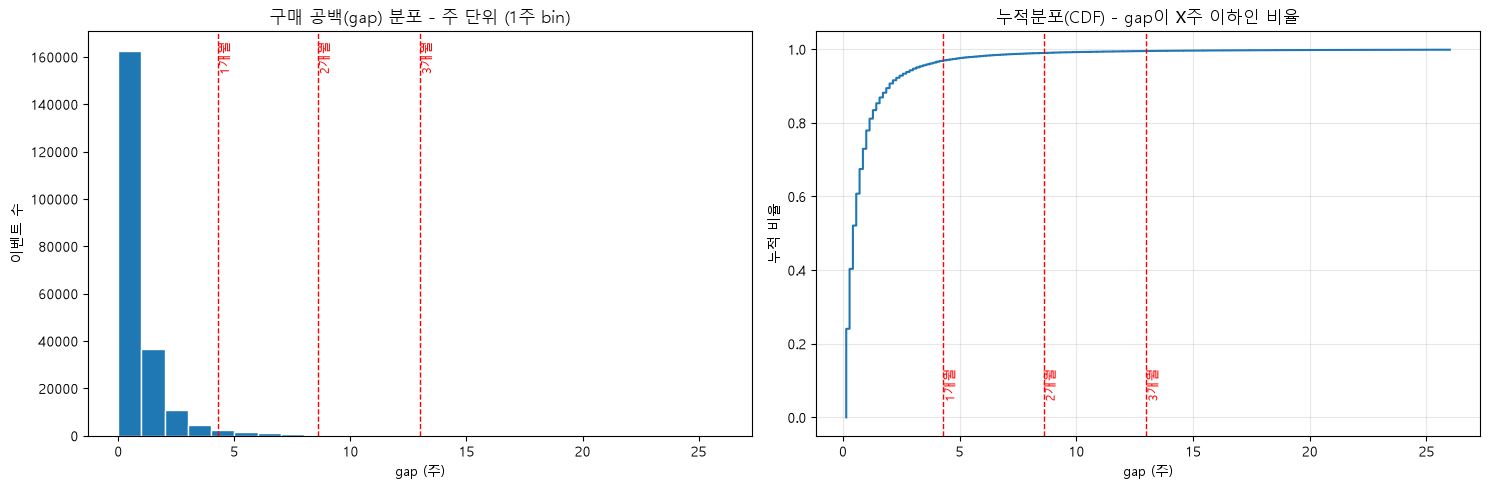

In [13]:
max_week_view = 26  # 0~26주 구간을 1주 단위로 확인 (필요시 조정)

gap_weeks_clip = gaps["gap_weeks"][gaps["gap_weeks"] <= max_week_view]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (좌) 히스토그램 - 1주 단위 bin
bins = np.arange(0, max_week_view + 1, 1)
axes[0].hist(gap_weeks_clip, bins=bins, edgecolor='white')
for wk, label in [(4.3, '1개월'), (8.6, '2개월'), (13, '3개월')]:
    axes[0].axvline(wk, color='red', linestyle='--', linewidth=1)
    axes[0].text(wk, axes[0].get_ylim()[1]*0.9, label, rotation=90, color='red', fontsize=9)
axes[0].set_title("구매 공백(gap) 분포 - 주 단위 (1주 bin)")
axes[0].set_xlabel("gap (주)")
axes[0].set_ylabel("이벤트 수")

# (우) 누적분포(CDF) - 몇 주 이상 쉬면 전체 gap 중 몇 %가 되는지
sorted_gaps = np.sort(gap_weeks_clip)
cdf = np.arange(1, len(sorted_gaps) + 1) / len(gaps)  # 전체 gap 기준 누적비율
axes[1].plot(sorted_gaps, cdf)
for wk, label in [(4.3, '1개월'), (8.6, '2개월'), (13, '3개월')]:
    axes[1].axvline(wk, color='red', linestyle='--', linewidth=1)
    axes[1].text(wk, 0.05, label, rotation=90, color='red', fontsize=9)
axes[1].set_title("누적분포(CDF) - gap이 X주 이하인 비율")
axes[1].set_xlabel("gap (주)")
axes[1].set_ylabel("누적 비율")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Elbow(변곡점) 자동 탐지 시도

`kneed` 패키지가 있으면 자동으로 변곡점을 잡아보고, 없으면 수동으로 기울기 변화가 가장 큰 지점을 찾는다.
(전체 gap 분포가 아니라, 재구매 확률이 급격히 낮아지는 지점을 보기 위해 **1주 단위 gap 발생 빈도의 감소율**을 사용)


In [14]:
counts, edges = np.histogram(gap_weeks_clip, bins=bins)
week_centers = (edges[:-1] + edges[1:]) / 2

try:
    from kneed import KneeLocator
    kl = KneeLocator(week_centers, counts, curve="convex", direction="decreasing")
    print(f"kneed 패키지 기준 elbow 지점: 약 {kl.knee:.1f}주")
except ImportError:
    # 수동 방식: 인접 구간 대비 감소율(%)이 가장 큰 지점을 근사 elbow로 사용
    pct_change = -np.diff(counts) / counts[:-1].clip(min=1) * 100
    elbow_idx = np.argmax(pct_change[:20])  # 20주 이내에서만 탐색
    print(f"(kneed 미설치 - 수동 근사) 감소율이 가장 큰 구간: 약 {week_centers[elbow_idx]:.1f}주 부근")
    print("정확한 자동 탐지를 원하면: pip install kneed --break-system-packages")

print("\n주 단위 gap 빈도 (0~20주)")
for w, c in zip(week_centers[:20], counts[:20]):
    print(f"  {w:5.1f}주 : {c:6d}건")


(kneed 미설치 - 수동 근사) 감소율이 가장 큰 구간: 약 0.5주 부근
정확한 자동 탐지를 원하면: pip install kneed --break-system-packages

주 단위 gap 빈도 (0~20주)
    0.5주 : 162655건
    1.5주 :  36760건
    2.5주 :  10771건
    3.5주 :   4654건
    4.5주 :   2562건
    5.5주 :   1383건
    6.5주 :    974건
    7.5주 :    644건
    8.5주 :    473건
    9.5주 :    355건
   10.5주 :    249건
   11.5주 :    226건
   12.5주 :    190건
   13.5주 :    158건
   14.5주 :    111건
   15.5주 :     92건
   16.5주 :     76건
   17.5주 :     70건
   18.5주 :     65건
   19.5주 :     51건


## 5. 정상주기 대비 배수(gap_ratio) 기준으로도 동일하게 확인

절대 주(week) 수 대신 "정상 구매주기의 몇 배"를 기준으로 봤을 때도 같은 지점에서 꺾이는지 교차 확인.


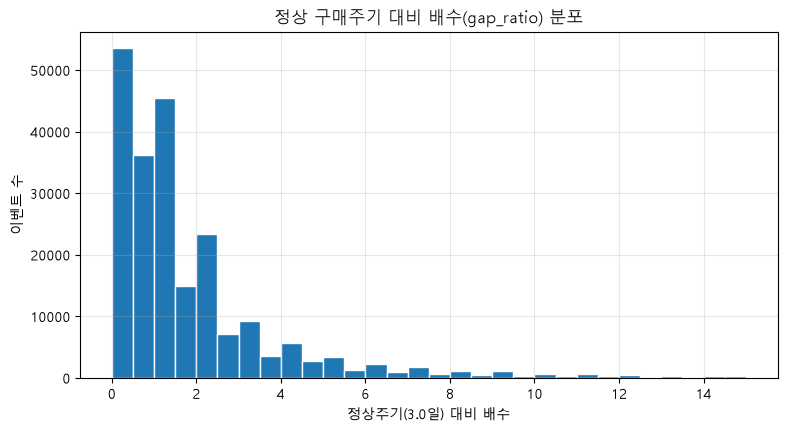

배수 구간별 이벤트 수
gap_ratio
(0, 2]       162655
(2, 4]        33967
(4, 6]        11553
(6, 8]         5079
(8, 10]        2935
(10, 15]       3224
(15, 999]      3620
Name: count, dtype: int64


In [15]:
max_ratio_view = 15

ratio_clip = gaps["gap_ratio"][gaps["gap_ratio"] <= max_ratio_view]
ratio_bins = np.arange(0, max_ratio_view + 0.5, 0.5)

plt.figure(figsize=(9, 4.5))
plt.hist(ratio_clip, bins=ratio_bins, edgecolor='white')
plt.title("정상 구매주기 대비 배수(gap_ratio) 분포")
plt.xlabel(f"정상주기({normal_cycle_days:.1f}일) 대비 배수")
plt.ylabel("이벤트 수")
plt.grid(alpha=0.3)
plt.show()

print("배수 구간별 이벤트 수")
print(pd.cut(gaps['gap_ratio'], bins=[0,2,4,6,8,10,15,999]).value_counts().sort_index())


## 6. 가구(household) 단위로 재구성 — 컷오프 후보별 영향받는 가구 수

팀원의 분석은 **이벤트 단위**(한 가구가 여러 번 재활성화될 수 있음)였다.
여기서는 **가구 단위**로, 각 가구의 "가장 긴 공백(max gap)"을 기준으로 후보 컷오프별 몇 가구가 "재활성화 가구"로 분류되는지 확인한다.
(한 가구가 재활성화 이벤트를 여러 번 가져도 1건으로만 집계됨 — 중복 카운트 방지)


In [16]:
# 가구별 최장 공백
household_max_gap = gaps.groupby("household_key")["gap_days"].max().reset_index()
household_max_gap.columns = ["household_key", "max_gap_days"]
household_max_gap["max_gap_weeks"] = household_max_gap["max_gap_days"] / 7

total_households = tx["household_key"].nunique()
print(f"전체 가구 수: {total_households:,}")
print(f"gap 이벤트가 1건 이상 있는 가구 수: {len(household_max_gap):,}")

candidate_cutoffs_weeks = [2, 4, 6, 8, 10, 13, 17, 26]  # 약 2주~6개월

rows = []
for wk in candidate_cutoffs_weeks:
    n_households = (household_max_gap["max_gap_weeks"] >= wk).sum()
    rows.append({
        "컷오프(주)": wk,
        "컷오프(개월 환산)": round(wk / 4.3, 1),
        "재활성화로 분류될 가구 수": n_households,
        "전체 가구 대비 비율(%)": round(n_households / total_households * 100, 1),
    })

cutoff_table = pd.DataFrame(rows)
cutoff_table


전체 가구 수: 2,500
gap 이벤트가 1건 이상 있는 가구 수: 2,497


,컷오프(주),컷오프(개월 환산),재활성화로 분류될 가구 수,전체 가구 대비 비율(%)
0,2,0.5,2369,94.8
1,4,0.9,1928,77.1
2,6,1.4,1538,61.5
3,8,1.9,1264,50.6
4,10,2.3,1056,42.2
5,13,3.0,789,31.6
6,17,4.0,562,22.5
7,26,6.0,307,12.3


In [17]:
# 참고용: 팀원이 제안한 3개월(=13주) 컷오프가 표에서 어디에 해당하는지 강조
print("팀원 제안(3개월 = 약 13주) 기준 결과:")
print(cutoff_table[cutoff_table["컷오프(주)"] == 13])


팀원 제안(3개월 = 약 13주) 기준 결과:
   컷오프(주)  컷오프(개월 환산)  재활성화로 분류될 가구 수  전체 가구 대비 비율(%)
5      13         3.0             789            31.6


## 7. 다음 단계 메모

- 위 3, 4번 시각화에서 실제 꺾이는 지점(elbow)이 몇 주인지 확인 → 팀원이 제안한 13주(3개월)와 비교
- 6번 표를 근거로, 컷오프를 옮겼을 때 재활성화 가구 수가 얼마나 민감하게 변하는지 확인
  (너무 급격히 변한다면 그 구간이 아직 불안정한 경계 — 완만해지는 지점을 최종 컷오프로 추천)
- 최종 컷오프가 정해지면, `household_max_gap`에 `household_key`별 `customer_type`(신규/재활성화/기존) 라벨을 붙여서
  H1 산출물 형식(household_key | customer_type)으로 정리 → H4-2 교차표에 바로 연결
